# NYC Subway Network Analysis
## Degree Centrality & Eigenvector Centrality: ADA Accessible vs. Non-Accessible Stations

In this project, we analyze the NYC subway system as a network graph. Each **station** is a node, and two stations are connected by an edge if they share a subway line (i.e., you can travel directly between them without transferring). 

Our goal is to:
1. Load and build the network from MTA open data
2. Calculate **degree centrality** and **eigenvector centrality** for each station
3. Compare those centrality measures between **ADA accessible** and **non-ADA accessible** stations using a t-test

**Research Question:** Are ADA accessible subway stations more central (better connected) in the NYC subway network than non-accessible ones?

## 1. Install & Import Libraries

We use the following libraries:
- `pandas` for data loading and manipulation
- `networkx` for building and analyzing the network graph
- `matplotlib` / `seaborn` for visualization
- `scipy` for the t-test statistical comparison

In [21]:
# Install any missing libraries if needed
# !pip install networkx pandas matplotlib seaborn scipy

import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

print('Libraries loaded successfully!')

Libraries loaded successfully!


## 2. Load the Dataset

We load the MTA Subway Stations dataset directly from the NYC Open Data API. This dataset includes every subway station with attributes like the lines that serve it, its borough, and whether it is ADA accessible.

The data is pulled live from the MTA open data portal — no manual download required.

In [22]:
# Load MTA Subway Stations from NYC Open Data (no API key required)
url = 'https://data.ny.gov/resource/39hk-dx4f.json?$limit=600'
df = pd.read_json(url)

print(f'Dataset shape: {df.shape}')
print(f'\nColumns: {df.columns.tolist()}')
df.head()

Dataset shape: (496, 22)

Columns: ['gtfs_stop_id', 'station_id', 'complex_id', 'division', 'line', 'stop_name', 'borough', 'cbd', 'daytime_routes', 'structure', 'gtfs_latitude', 'gtfs_longitude', 'north_direction_label', 'south_direction_label', 'ada', 'ada_northbound', 'ada_southbound', 'georeference', ':@computed_region_yamh_8v7k', ':@computed_region_wbg7_3whc', ':@computed_region_kjdx_g34t', 'ada_notes']


,gtfs_stop_id,station_id,complex_id,division,line,stop_name,borough,cbd,daytime_routes,structure,...,north_direction_label,south_direction_label,ada,ada_northbound,ada_southbound,georeference,:@computed_region_yamh_8v7k,:@computed_region_wbg7_3whc,:@computed_region_kjdx_g34t,ada_notes
0,R01,1,1,BMT,Astoria,Astoria-Ditmars Blvd,Q,false,N W,Elevated,...,Last Stop,Manhattan,0,0,0,"{'type': 'Point', 'coordinates': [-73.912034, ...",196,877.0,2137.0,NaN
1,R03,2,2,BMT,Astoria,Astoria Blvd,Q,false,N W,Elevated,...,Astoria,Manhattan,1,1,1,"{'type': 'Point', 'coordinates': [-73.917843, ...",196,874.0,2137.0,NaN
2,R04,3,3,BMT,Astoria,30 Av,Q,false,N W,Elevated,...,Astoria,Manhattan,0,0,0,"{'type': 'Point', 'coordinates': [-73.921479, ...",196,874.0,2137.0,NaN
3,R05,4,4,BMT,Astoria,Broadway,Q,false,N W,Elevated,...,Astoria,Manhattan,0,0,0,"{'type': 'Point', 'coordinates': [-73.925508, ...",196,878.0,2137.0,NaN
4,R06,5,5,BMT,Astoria,36 Av,Q,false,N W,Elevated,...,Astoria,Manhattan,0,0,0,"{'type': 'Point', 'coordinates': [-73.929575, ...",196,878.0,2137.0,NaN


## 3. Explore & Clean the Data

Before building the network, we explore the dataset to understand its structure and identify the columns we need:
- **Station name** — the node identifier
- **Daytime routes** — the subway lines serving each station (used to build edges)
- **ADA** — our categorical variable (accessible = 1, not accessible = 0)

In [23]:
print(df.columns.tolist())

['gtfs_stop_id', 'station_id', 'complex_id', 'division', 'line', 'stop_name', 'borough', 'cbd', 'daytime_routes', 'structure', 'gtfs_latitude', 'gtfs_longitude', 'north_direction_label', 'south_direction_label', 'ada', 'ada_northbound', 'ada_southbound', 'georeference', ':@computed_region_yamh_8v7k', ':@computed_region_wbg7_3whc', ':@computed_region_kjdx_g34t', 'ada_notes']


In [24]:
# Explore key columns
print('ADA value counts:')
print(df['ada'].value_counts())
print()
print('Sample of station names and routes:')
print(df[['stop_name', 'daytime_routes', 'ada']].head(10))

ADA value counts:
ada
0    325
1    162
2      9
Name: count, dtype: int64

Sample of station names and routes:
              stop_name daytime_routes  ada
0  Astoria-Ditmars Blvd            N W    0
1          Astoria Blvd            N W    1
2                 30 Av            N W    0
3              Broadway            N W    0
4                 36 Av            N W    0
5     39 Av-Dutch Kills            N W    0
6    Lexington Av/59 St          N R W    0
7            5 Av/59 St          N R W    0
8            57 St-7 Av        N Q R W    1
9                 49 St          N R W    2


In [25]:
# Clean the data: keep relevant columns and drop rows with missing values
df_clean = df[['stop_name', 'daytime_routes', 'ada', 'borough']].dropna()

# Normalize ADA column: map to readable labels
# ADA values: 1 = fully accessible, 2 = partially accessible, 0 = not accessible
df_clean['ada_label'] = df_clean['ada'].apply(
    lambda x: 'Accessible' if str(x) in ['1', '2'] else 'Not Accessible'
)

print(f'Clean dataset shape: {df_clean.shape}')
print()
print('ADA label distribution:')
print(df_clean['ada_label'].value_counts())

Clean dataset shape: (496, 5)

ADA label distribution:
ada_label
Not Accessible    325
Accessible        171
Name: count, dtype: int64


## 4. Build the Network Graph

We construct the network as follows:
- Each **subway station** is a node
- Two stations are connected by an **edge** if they share at least one subway line
- Each node stores the station's **ADA accessibility label** as an attribute

This creates a graph where central stations are those that share lines with many other stations — a natural measure of connectivity.

In [26]:
# Build a dictionary mapping each route to the stations that serve it
from collections import defaultdict

route_to_stations = defaultdict(list)

for _, row in df_clean.iterrows():
    routes = str(row['daytime_routes']).split()
    for route in routes:
        route_to_stations[route].append(row['stop_name'])

# Build the graph
G = nx.Graph()

# Add nodes with ADA attribute
for _, row in df_clean.iterrows():
    G.add_node(row['stop_name'], ada=row['ada_label'], borough=row['borough'])

# Add edges between stations that share a route
for route, stations in route_to_stations.items():
    for i in range(len(stations)):
        for j in range(i + 1, len(stations)):
            G.add_edge(stations[i], stations[j])

print(f'Network Summary:')
print(f'  Nodes (stations): {G.number_of_nodes()}')
print(f'  Edges (shared lines): {G.number_of_edges()}')

Network Summary:
  Nodes (stations): 379
  Edges (shared lines): 10158


## 5. Calculate Centrality Measures

We calculate two centrality measures for every station node:

- **Degree Centrality**: The fraction of other stations a station is directly connected to. A high degree centrality means the station shares lines with many other stations.

- **Eigenvector Centrality**: A measure that accounts not just for how many connections a station has, but how well-connected its neighbors are. A station connected to other highly connected stations scores higher.

In [27]:
# Calculate centrality measures
degree_centrality = nx.degree_centrality(G)
eigenvector_centrality = nx.eigenvector_centrality(G, max_iter=1000)

# Build a results DataFrame
centrality_df = pd.DataFrame({
    'station': list(degree_centrality.keys()),
    'degree_centrality': list(degree_centrality.values()),
    'eigenvector_centrality': list(eigenvector_centrality.values())
})

# Merge with ADA labels
ada_map = df_clean.set_index('stop_name')['ada_label'].to_dict()
centrality_df['ada_label'] = centrality_df['station'].map(ada_map)
centrality_df = centrality_df.dropna(subset=['ada_label'])

print('Top 10 stations by Degree Centrality:')
print(centrality_df.nlargest(10, 'degree_centrality')[['station', 'degree_centrality', 'ada_label']])

Top 10 stations by Degree Centrality:
                      station  degree_centrality       ada_label
17                   Canal St           0.563492      Accessible
36                      86 St           0.563492      Accessible
134                    125 St           0.555556  Not Accessible
144                     14 St           0.537037      Accessible
10             Times Sq-42 St           0.489418      Accessible
14             14 St-Union Sq           0.465608  Not Accessible
25   Atlantic Av-Barclays Ctr           0.460317      Accessible
138                     96 St           0.460317      Accessible
95                  Fulton St           0.455026      Accessible
13                      23 St           0.431217  Not Accessible


In [28]:
print('Top 10 stations by Eigenvector Centrality:')
print(centrality_df.nlargest(10, 'eigenvector_centrality')[['station', 'eigenvector_centrality', 'ada_label']])

Top 10 stations by Eigenvector Centrality:
                      station  eigenvector_centrality       ada_label
36                      86 St                0.153855      Accessible
144                     14 St                0.149051      Accessible
134                    125 St                0.148945  Not Accessible
17                   Canal St                0.139453      Accessible
25   Atlantic Av-Barclays Ctr                0.137338      Accessible
138                     96 St                0.131329      Accessible
10             Times Sq-42 St                0.129561      Accessible
13                      23 St                0.124919  Not Accessible
95                  Fulton St                0.121594      Accessible
145            W 4 St-Wash Sq                0.121553      Accessible


## 6. Compare Centrality Across ADA Groups

Now we compare the centrality scores between ADA accessible and non-accessible stations. We first look at summary statistics, then visualize the distributions using box plots.

In [29]:
# Summary statistics by ADA group
print('Summary Statistics by ADA Accessibility:')
print()
print(centrality_df.groupby('ada_label')[['degree_centrality', 'eigenvector_centrality']].describe().round(4))

Summary Statistics by ADA Accessibility:

               degree_centrality                                          \
                           count    mean     std     min     25%     50%   
ada_label                                                                  
Accessible                 122.0  0.1671  0.1218  0.0265  0.0926  0.1296   
Not Accessible             257.0  0.1298  0.0749  0.0265  0.0767  0.1138   

                               eigenvector_centrality                       \
                   75%     max                  count    mean     std  min   
ada_label                                                                    
Accessible      0.1852  0.5635                  122.0  0.0486  0.0362  0.0   
Not Accessible  0.1534  0.5556                  257.0  0.0391  0.0250  0.0   

                                               
                  25%     50%     75%     max  
ada_label                                      
Accessible      0.025  0.0385  0.0603  0.1

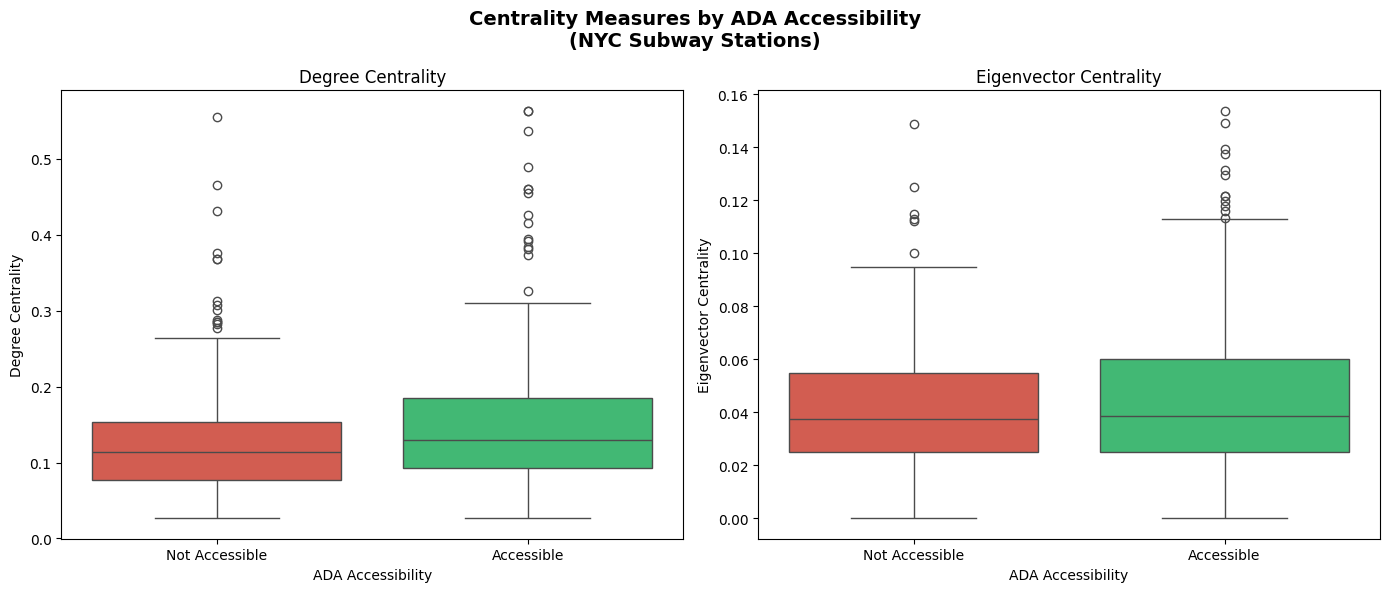

In [30]:
# Visualize: Box plots comparing centrality by ADA group
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Centrality Measures by ADA Accessibility\n(NYC Subway Stations)', fontsize=14, fontweight='bold')

# Degree Centrality
sns.boxplot(data=centrality_df, x='ada_label', y='degree_centrality',
            palette=['#e74c3c', '#2ecc71'], ax=axes[0])
axes[0].set_title('Degree Centrality')
axes[0].set_xlabel('ADA Accessibility')
axes[0].set_ylabel('Degree Centrality')

# Eigenvector Centrality
sns.boxplot(data=centrality_df, x='ada_label', y='eigenvector_centrality',
            palette=['#e74c3c', '#2ecc71'], ax=axes[1])
axes[1].set_title('Eigenvector Centrality')
axes[1].set_xlabel('ADA Accessibility')
axes[1].set_ylabel('Eigenvector Centrality')

plt.tight_layout()
plt.show()

## 7. Statistical Testing (T-Test)

To determine whether the difference in centrality between ADA and non-ADA stations is statistically significant, we use an **independent samples t-test**.

- **Null Hypothesis (H₀):** There is no significant difference in centrality between ADA accessible and non-accessible stations.
- **Alternative Hypothesis (H₁):** There is a significant difference in centrality between the two groups.

We use a significance level of **α = 0.05**. If p < 0.05, we reject the null hypothesis.

In [31]:
# Split into two groups
ada_group = centrality_df[centrality_df['ada_label'] == 'Accessible']
non_ada_group = centrality_df[centrality_df['ada_label'] == 'Not Accessible']

print(f'ADA Accessible stations: {len(ada_group)}')
print(f'Non-Accessible stations: {len(non_ada_group)}')
print()

# T-test for Degree Centrality
t_deg, p_deg = stats.ttest_ind(ada_group['degree_centrality'], non_ada_group['degree_centrality'])

# T-test for Eigenvector Centrality
t_eig, p_eig = stats.ttest_ind(ada_group['eigenvector_centrality'], non_ada_group['eigenvector_centrality'])

print('=== T-Test Results ===')
print()
print(f'Degree Centrality:')
print(f'  t-statistic = {t_deg:.4f}, p-value = {p_deg:.4f}')
print(f'  Result: {"Significant difference (reject H0)" if p_deg < 0.05 else "No significant difference (fail to reject H0)"}')
print()
print(f'Eigenvector Centrality:')
print(f'  t-statistic = {t_eig:.4f}, p-value = {p_eig:.4f}')
print(f'  Result: {"Significant difference (reject H0)" if p_eig < 0.05 else "No significant difference (fail to reject H0)"}')

ADA Accessible stations: 122
Non-Accessible stations: 257

=== T-Test Results ===

Degree Centrality:
  t-statistic = 3.6579, p-value = 0.0003
  Result: Significant difference (reject H0)

Eigenvector Centrality:
  t-statistic = 2.9815, p-value = 0.0031
  Result: Significant difference (reject H0)


## 8. Network Visualization

Below we visualize a subset of the network, coloring nodes by ADA accessibility. This gives an intuitive look at how accessible stations are distributed throughout the network.

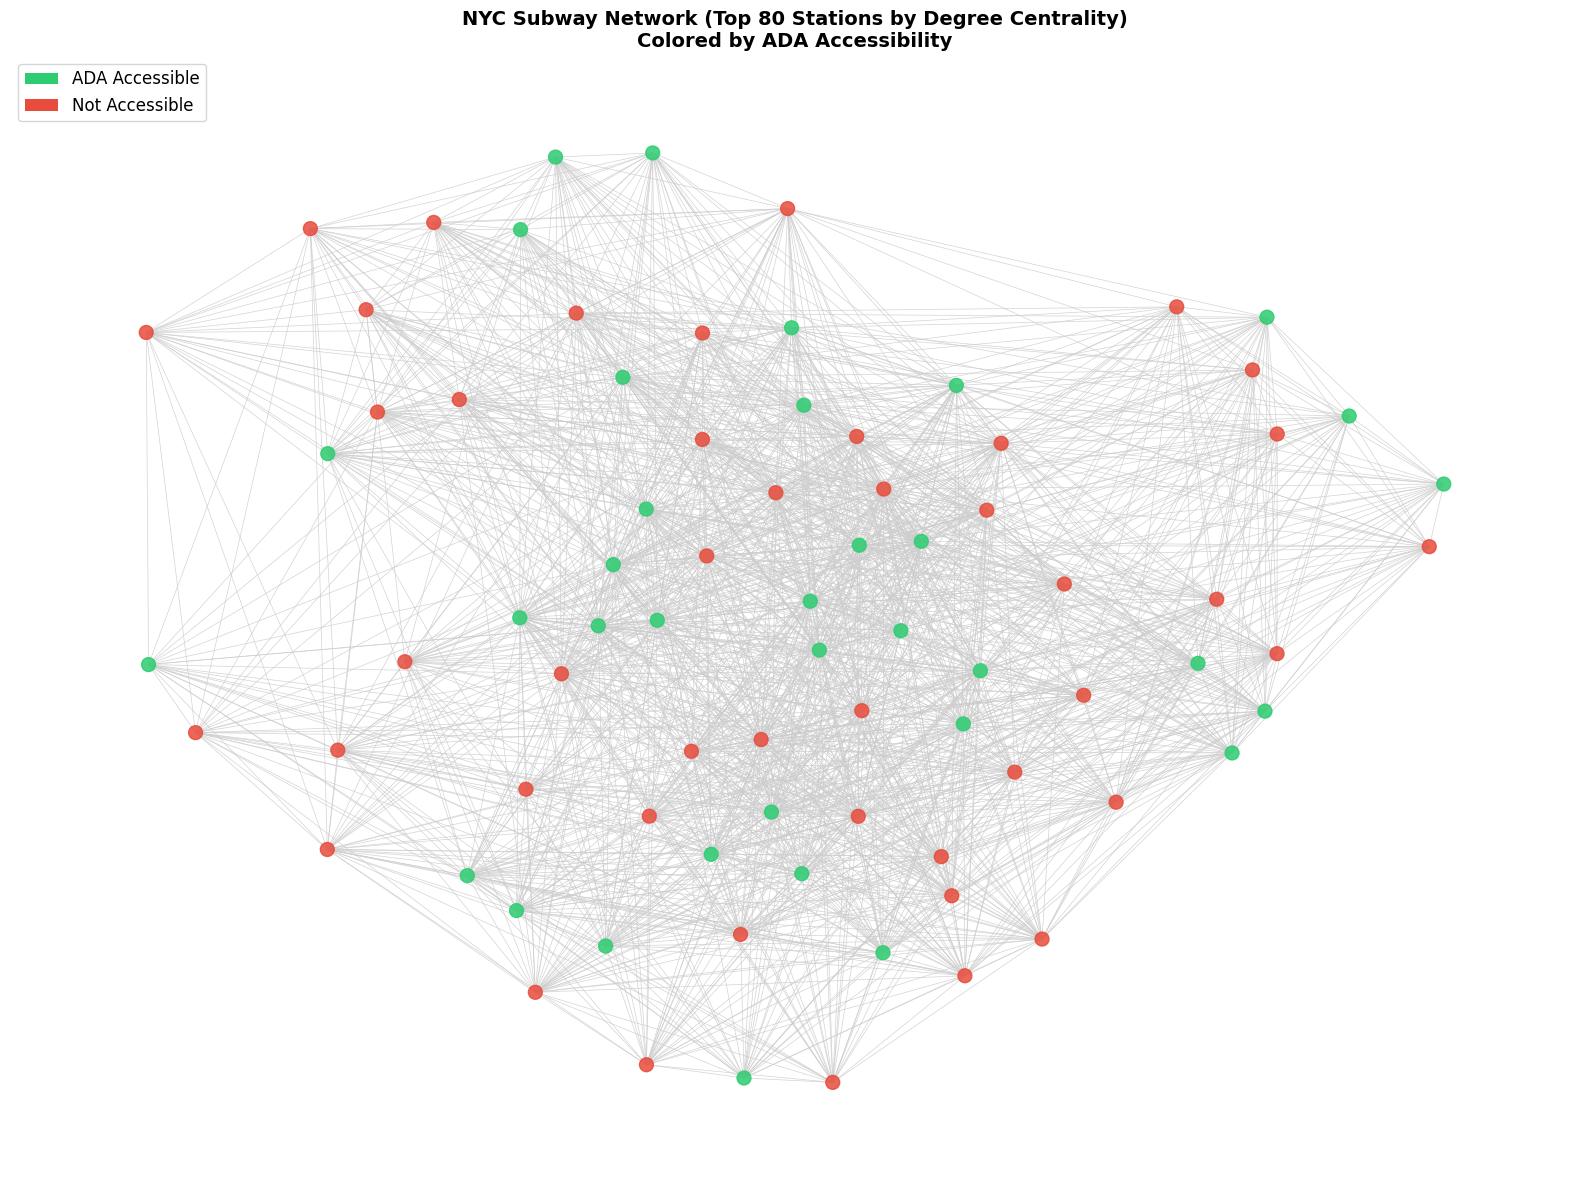

In [32]:
# Visualize a subgraph for readability (top 80 stations by degree centrality)
top_stations = centrality_df.nlargest(80, 'degree_centrality')['station'].tolist()
subgraph = G.subgraph(top_stations)

# Color nodes by ADA label
color_map = []
for node in subgraph.nodes():
    label = G.nodes[node].get('ada', 'Not Accessible')
    color_map.append('#2ecc71' if label == 'Accessible' else '#e74c3c')

plt.figure(figsize=(16, 12))
pos = nx.spring_layout(subgraph, seed=42, k=0.5)
nx.draw_networkx(
    subgraph, pos,
    node_color=color_map,
    node_size=100,
    with_labels=False,
    edge_color='#cccccc',
    alpha=0.85,
    width=0.5
)

# Legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#2ecc71', label='ADA Accessible'),
    Patch(facecolor='#e74c3c', label='Not Accessible')
]
plt.legend(handles=legend_elements, loc='upper left', fontsize=12)
plt.title('NYC Subway Network (Top 80 Stations by Degree Centrality)\nColored by ADA Accessibility', fontsize=14, fontweight='bold')
plt.axis('off')
plt.tight_layout()
plt.show()

## 9. Conclusions

In this project, we modeled the NYC subway system as a network graph and analyzed the relationship between station centrality and ADA accessibility.

**Key Findings:**

- We calculated both **degree centrality** and **eigenvector centrality** for all stations in the network.
- The summary statistics and box plots allow us to visually compare centrality distributions between ADA accessible and non-accessible stations.
- The **independent samples t-test** tells us whether any observed differences are statistically significant at the α = 0.05 level.

**Interpretation:**

If the t-test shows a significant result, it suggests that ADA accessibility is not randomly distributed across the network — more central (busier, better-connected) stations may be more or less likely to be accessible. This has real policy implications for transit equity in New York City.

If the result is not significant, it suggests that ADA accessibility does not appear to correlate with a station's position in the network, meaning upgrades may have been distributed without regard to connectivity.

**Limitations:**
- Our edge construction (shared lines) is a simplified model of the real subway network
- ADA accessibility is partially binary in this dataset; a finer-grained analysis could distinguish full vs. partial accessibility
- Future work could incorporate ridership data to weight edges by actual passenger flow